Threshold=0.00 | Cechy: 30 | Accuracy: 0.9561
Threshold=2.00 | Cechy: 10 | Accuracy: 0.9561
Threshold=4.00 | Cechy: 9 | Accuracy: 0.9561
Threshold=6.00 | Cechy: 9 | Accuracy: 0.9561
Threshold=8.00 | Cechy: 9 | Accuracy: 0.9561
Threshold=10.00 | Cechy: 9 | Accuracy: 0.9561
Threshold=12.00 | Cechy: 9 | Accuracy: 0.9561
Threshold=14.00 | Cechy: 8 | Accuracy: 0.9386
Threshold=16.00 | Cechy: 8 | Accuracy: 0.9386
Threshold=18.00 | Cechy: 8 | Accuracy: 0.9386
Threshold=20.00 | Cechy: 7 | Accuracy: 0.9211
Threshold=22.00 | Cechy: 7 | Accuracy: 0.9211
Threshold=24.00 | Cechy: 6 | Accuracy: 0.9386
Threshold=26.00 | Cechy: 6 | Accuracy: 0.9386
Threshold=28.00 | Cechy: 6 | Accuracy: 0.9386
Threshold=30.00 | Cechy: 6 | Accuracy: 0.9386
Threshold=32.00 | Cechy: 6 | Accuracy: 0.9386
Threshold=34.00 | Cechy: 6 | Accuracy: 0.9386
Threshold=36.00 | Cechy: 6 | Accuracy: 0.9386
Threshold=38.00 | Cechy: 6 | Accuracy: 0.9386
Threshold=40.00 | Cechy: 5 | Accuracy: 0.9737
Threshold=42.00 | Cechy: 5 | Accuracy

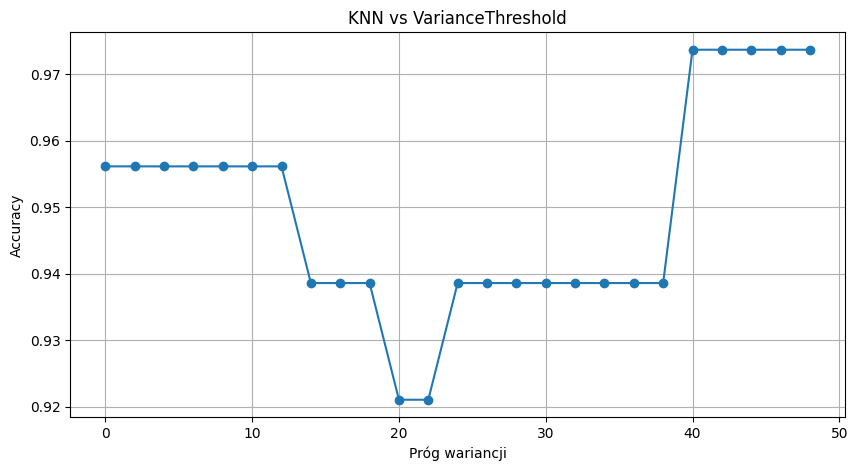

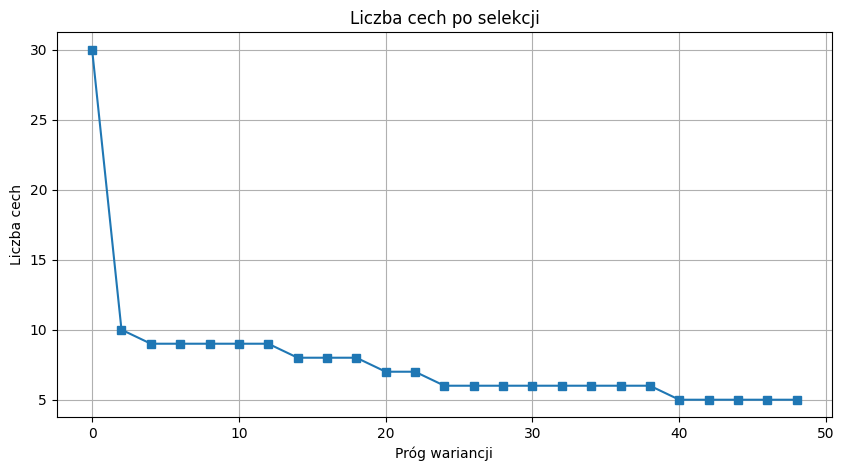

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import VarianceThreshold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Wczytaj dane
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# 2. Podział na train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Lista progów
thresholds = np.arange(0.0, 50.0, 2.0)
accuracies = []
num_features = []

# 4. Testowanie progów
for t in thresholds:
    selector = VarianceThreshold(threshold=t)

    try:
        # selekcja na TRAIN
        X_train_sel = selector.fit_transform(X_train)
        X_test_sel = selector.transform(X_test)

        # liczba cech
        kept_features = X_train_sel.shape[1]

        # skalowanie PO selekcji
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_sel)
        X_test_scaled = scaler.transform(X_test_sel)

        # model
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(X_train_scaled, y_train)

        acc = knn.score(X_test_scaled, y_test)

        accuracies.append(acc)
        num_features.append(kept_features)

        print(f"Threshold={t:.2f} | Cechy: {kept_features} | Accuracy: {acc:.4f}")

    except ValueError:
        accuracies.append(np.nan)
        num_features.append(0)
        print(f"Threshold={t:.2f} | Cechy: 0 | Accuracy: brak")

# 5. Wykres accuracy
plt.figure(figsize=(10,5))
plt.plot(thresholds, accuracies, marker='o')
plt.xlabel("Próg wariancji")
plt.ylabel("Accuracy")
plt.title("KNN vs VarianceThreshold")
plt.grid(True)
plt.show()

# 6. Wykres liczby cech
plt.figure(figsize=(10,5))
plt.plot(thresholds, num_features, marker='s')
plt.xlabel("Próg wariancji")
plt.ylabel("Liczba cech")
plt.title("Liczba cech po selekcji")
plt.grid(True)
plt.show()